In [1]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn as sns

print("Library Versions")
print("-" * 40)
print(f"Pandas         : {pd.__version__}")
print(f"NumPy          : {np.__version__}")
print(f"Scikit-learn   : {sklearn.__version__}")
print(f"Matplotlib     : {matplotlib.__version__}")
print(f"Seaborn        : {sns.__version__}")

Library Versions
----------------------------------------
Pandas         : 2.2.3
NumPy          : 2.1.3
Scikit-learn   : 1.6.1
Matplotlib     : 3.10.0
Seaborn        : 0.13.2


In [2]:
from pandas import read_csv
df=read_csv("/content/parking_dataset.csv")

In [3]:
df.tail(5)

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,Date,Hour,Day,Month,DayOfWeek,IsWeekend,AvailableSpaces,OccupancyRate,Previous_Availability,Lag_2_Availability,Lag_3_Availability,Rolling_Average_Availability
35394,BHMBRCBRG02,1194,851,2016-12-19 16:30:35,2016-12-19,16,19,12,Monday,0,343,0.712730,274.0,151.0,77.0,167.333333
35395,BHMBRCBRG01,1010,857,2016-12-19 16:30:35,2016-12-19,16,19,12,Monday,0,153,0.848515,85.0,30.0,19.0,44.666667
35396,BHMBCCTHL01,387,387,2016-12-19 16:30:35,2016-12-19,16,19,12,Monday,0,0,1.000000,0.0,0.0,0.0,0.000000
35397,BHMNCPRAN01,600,376,2016-12-19 16:30:35,2016-12-19,16,19,12,Monday,0,224,0.626667,184.0,167.0,147.0,166.000000
35398,Shopping,1920,1180,2016-12-19 16:30:35,2016-12-19,16,19,12,Monday,0,740,0.614583,599.0,488.0,433.0,506.666667


In [6]:
df['Month']
df.shape

(35399, 16)

In [7]:
df.dtypes

,0
SystemCodeNumber,object
Capacity,int64
Occupancy,int64
LastUpdated,object
Date,object
Hour,int64
Day,int64
Month,int64
DayOfWeek,object
IsWeekend,int64


In [8]:
df.Month

,Month
0,10
1,10
2,10
3,10
4,10
...,...
35394,12
35395,12
35396,12
35397,12


In [9]:
missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})
missing_data

,Missing Values,Percentage
SystemCodeNumber,0,0.0
Capacity,0,0.0
Occupancy,0,0.0
LastUpdated,0,0.0
Date,0,0.0
Hour,0,0.0
Day,0,0.0
Month,0,0.0
DayOfWeek,0,0.0
IsWeekend,0,0.0


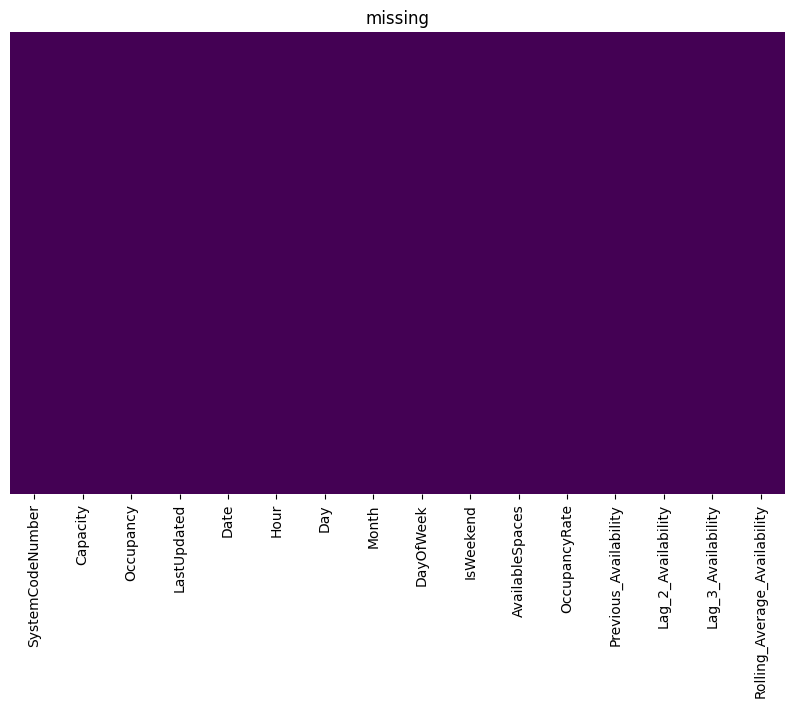

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
# cbar=False hides the color bar; yticklabels=False hides row numbers for cleaner v
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("missing")
plt.show()

In [11]:
duplicate_rows = df[df.duplicated()]
print(f"Total duplicate rows detected: {len(duplicate_rows)}")
print(duplicate_rows)
print("-" * 40)

Total duplicate rows detected: 0
Empty DataFrame
Columns: [SystemCodeNumber, Capacity, Occupancy, LastUpdated, Date, Hour, Day, Month, DayOfWeek, IsWeekend, AvailableSpaces, OccupancyRate, Previous_Availability, Lag_2_Availability, Lag_3_Availability, Rolling_Average_Availability]
Index: []
----------------------------------------


In [13]:
df[df['AvailableSpaces'].isnull()]

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,Date,Hour,Day,Month,DayOfWeek,IsWeekend,AvailableSpaces,OccupancyRate,Previous_Availability,Lag_2_Availability,Lag_3_Availability,Rolling_Average_Availability


In [14]:
df.duplicated().sum()
df = df.drop_duplicates()
duplicate_rows

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,Date,Hour,Day,Month,DayOfWeek,IsWeekend,AvailableSpaces,OccupancyRate,Previous_Availability,Lag_2_Availability,Lag_3_Availability,Rolling_Average_Availability


In [15]:
df.describe()

,Capacity,Occupancy,Hour,Day,Month,IsWeekend,AvailableSpaces,OccupancyRate,Previous_Availability,Lag_2_Availability,Lag_3_Availability,Rolling_Average_Availability
count,35399.000000,35399.000000,35399.000000,35399.000000,35399.000000,35399.000000,35399.000000,35399.000000,35399.000000,35399.000000,35399.000000,35399.000000
mean,1399.725529,645.755276,11.822368,15.135343,10.885449,0.264075,753.970253,0.495626,754.275658,754.707026,755.242888,754.741857
std,1180.075015,658.292714,2.599351,8.261347,0.752090,0.440846,786.518773,0.270425,786.798979,787.142717,787.531184,779.803758
min,220.000000,0.000000,7.000000,1.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,500.000000,212.000000,10.000000,8.000000,10.000000,0.000000,183.000000,0.258818,183.000000,184.000000,184.000000,187.666667
50%,863.000000,449.000000,12.000000,15.000000,11.000000,0.000000,477.000000,0.475361,477.000000,478.000000,478.000000,478.333333
75%,2009.000000,803.000000,14.000000,22.000000,11.000000,1.000000,1020.000000,0.719193,1021.000000,1021.000000,1021.000000,1018.333333
max,4675.000000,4327.000000,16.000000,31.000000,12.000000,1.000000,4151.000000,1.000000,4151.000000,4151.000000,4151.000000,4119.333333


In [16]:
df = df.drop_duplicates()

In [17]:
df.shape

(35399, 16)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
import pandas as pd
import numpy as np

In [20]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['Capacity', 'Occupancy', 'Hour', 'Day', 'Month', 'IsWeekend', 'AvailableSpaces', 'OccupancyRate', 'Previous_Availability', 'Lag_2_Availability', 'Lag_3_Availability', 'Rolling_Average_Availability']
Categorical Features: ['SystemCodeNumber', 'LastUpdated', 'Date', 'DayOfWeek']


<Figure size 1500x800 with 0 Axes>

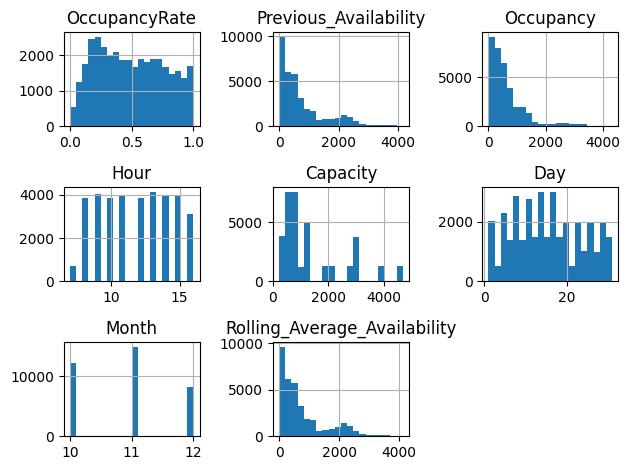

In [22]:
features = ["OccupancyRate", "Previous_Availability", "Occupancy", "Hour","Capacity", "Day","Month","Rolling_Average_Availability" ]

fig2=plt.figure(figsize=(15,8))
df[features].hist(
    bins=20
)

plt.tight_layout()

plt.show()

In [23]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", list(numerical_features))
print("Categorical Features:", list(categorical_features))

Numerical Features: ['Capacity', 'Occupancy', 'Hour', 'Day', 'Month', 'IsWeekend', 'AvailableSpaces', 'OccupancyRate', 'Previous_Availability', 'Lag_2_Availability', 'Lag_3_Availability', 'Rolling_Average_Availability']
Categorical Features: ['SystemCodeNumber', 'LastUpdated', 'Date', 'DayOfWeek']


In [24]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numerical_cols].corr()

In [25]:
print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
                              Capacity  Occupancy      Hour       Day  \
Capacity                      1.000000   0.777073  0.000071  0.001322   
Occupancy                     0.777073   1.000000  0.194661  0.004582   
Hour                          0.000071   0.194661  1.000000 -0.003524   
Day                           0.001322   0.004582 -0.003524  1.000000   
Month                         0.005621   0.060247 -0.000756 -0.305542   
IsWeekend                     0.012356  -0.086569 -0.006496  0.132912   
AvailableSpaces               0.849991   0.328933 -0.162818 -0.001852   
OccupancyRate                -0.150369   0.343966  0.339483 -0.018805   
Previous_Availability         0.850089   0.351352 -0.165530 -0.002046   
Lag_2_Availability            0.850231   0.384942 -0.153003 -0.002472   
Lag_3_Availability            0.850427   0.424688 -0.130747 -0.003010   
Rolling_Average_Availability  0.858267   0.390655 -0.151167 -0.002533   

                      

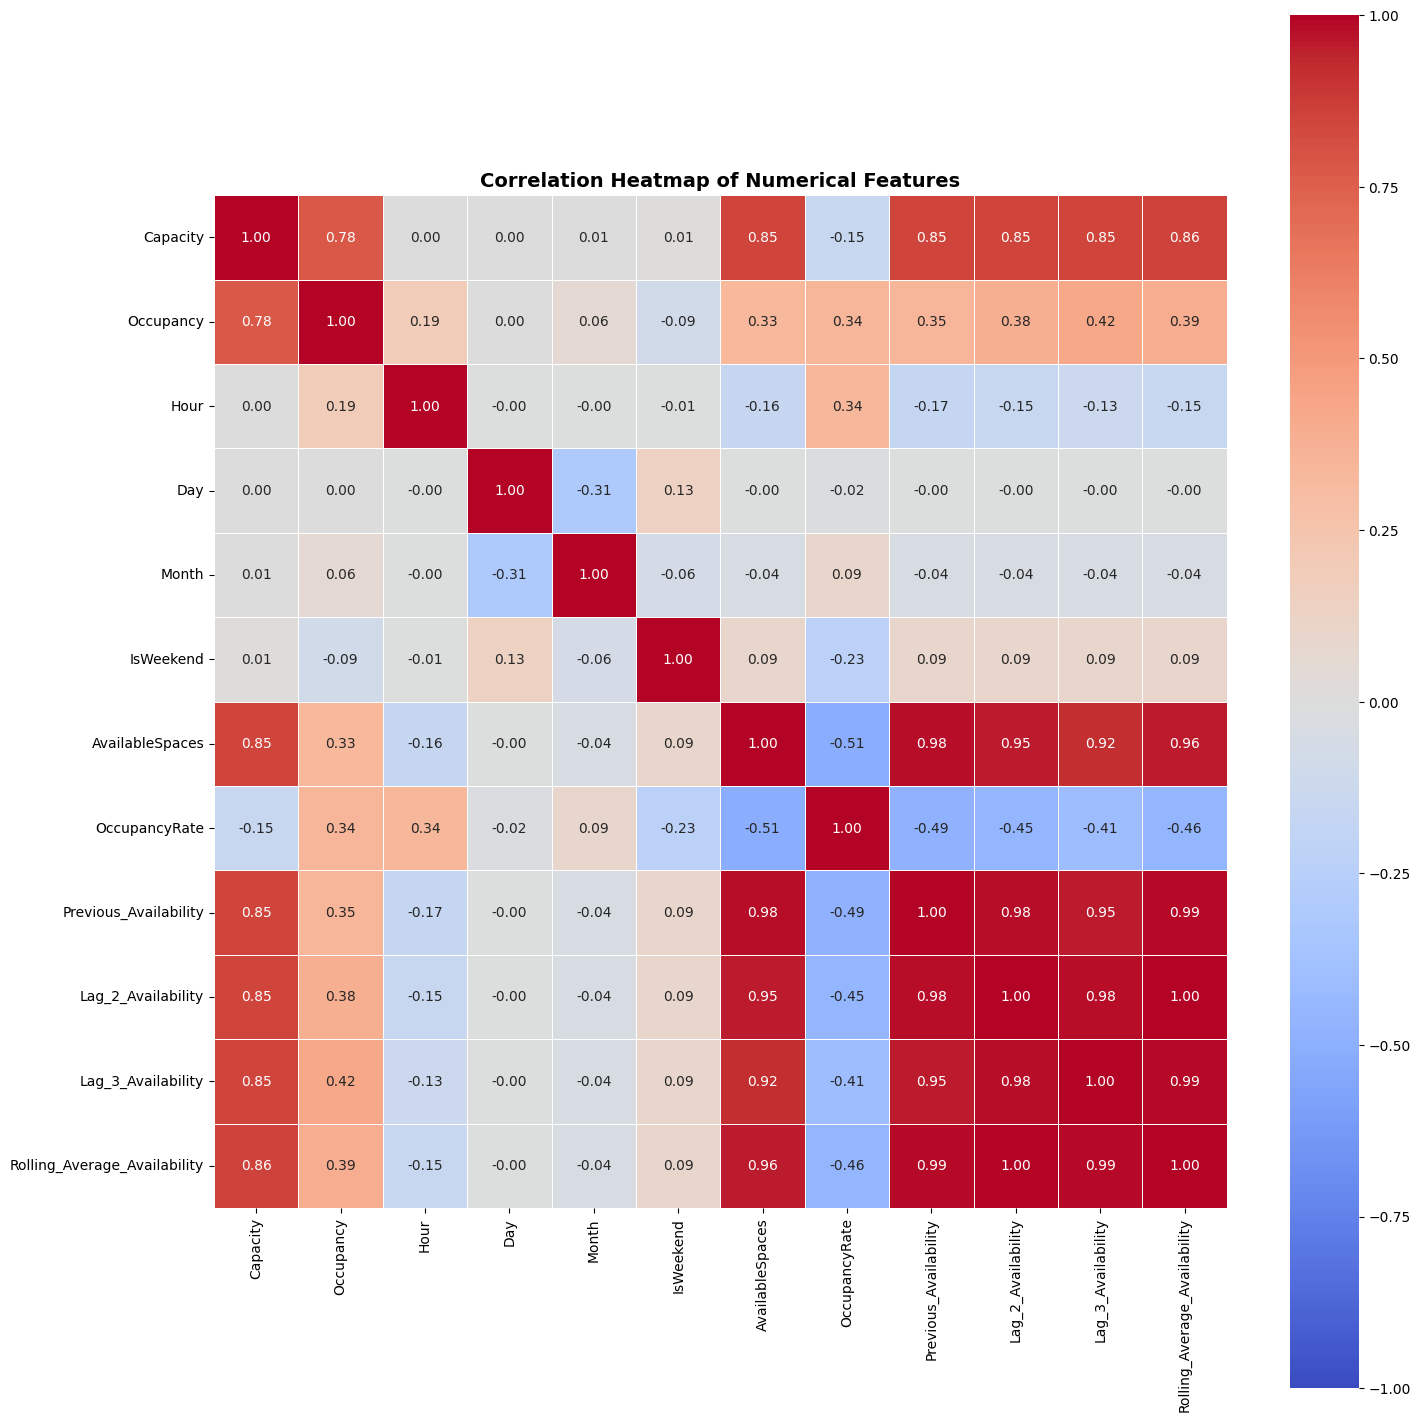

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f",
vmin=-1,
vmax=1,
square=True,
linewidths=0.5
)
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()

In [27]:
import os
output_dir = "/content/"
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, dpi=300)
plt.close()
print(f"Exported heatmap to: {heatmap_path}")

Exported heatmap to: /content/correlation_heatmap.png


In [28]:
target_col = "Parking space Availability"
if target_col in df.columns:
    for col in numerical_cols:
        plt.figure(figsize=(6, 5))
        sns.boxplot(
            x=target_col,
            y=col,
            data=df,
            palette="Set2",
            hue=target_col,
            legend=False
        )
        plt.title(f"{col} vs {target_col}", fontsize=12, fontweight="bold")
        plt.xlabel(target_col)
        plt.ylabel(col)
        plt.tight_layout()



        boxplot_filename = f"boxplot_{col}_vs_{target_col}.png"


        boxplot_path = os.path.join(output_dir, boxplot_filename)


        plt.savefig(boxplot_path,    dpi=300,    bbox_inches="tight")


        plt.close()

        print(f"Exported boxplot to: {boxplot_path}")

    else:
        print(f"\nTarget column '{target_col}' not found in dataset. Skipping boxplots.")

        print("\nAll EDA tasks completed successfully!")